In [27]:
import numpy as np
import xarray as xr
import os
import seawater
import matplotlib.pyplot as plt
import scipy.sparse
import scipy.sparse.linalg
import scipy
from scipy.stats import ttest_ind

In [10]:
def get_nc_var(file, var_name, start=None, count=None):
    
    with xr.open_dataset(file) as ds:
        if start is not None and count is not None:
            slices = tuple(slice(s, s + c) for s, c in zip(start, count))
            return ds[var_name].isel({dim: s for dim, s in zip(ds[var_name].dims, slices)}).values
        return ds[var_name].values

In [11]:
def build_poisson_matrix(dx, dy):
    ny, nx = dx.shape
    A = scipy.sparse.lil_matrix((nx * ny, nx * ny))

    for j in range(ny):
        for i in range(nx):
            idx = j * nx + i
            dx2 = dx[j, i] ** 2
            dy2 = dy[j, i] ** 2
            A[idx, idx] = -2 * (1/dx2 + 1/dy2)
            if i > 0:
                A[idx, idx - 1] = 1/dx2
            if i < nx - 1:
                A[idx, idx + 1] = 1/dx2
            if j > 0:
                A[idx, idx - nx] = 1/dy2
            if j < ny - 1:
                A[idx, idx + nx] = 1/dy2

    A[0, :] = 0
    A[0, 0] = 1

    return A.tocsr()

In [12]:
def prepare_poisson_solver(dx, dy):
    A = build_poisson_matrix(dx, dy)
    solver = scipy.sparse.linalg.factorized(A)
    return solver

In [13]:
def compute_vorticity(u, v, dx, dy):
    dudx = (u[2:, 1:-1] - u[:-2, 1:-1]) / (2 * dx[1:-1, 1:-1])
    dvdy = (v[1:-1, 2:] - v[1:-1, :-2]) / (2 * dy[1:-1, 1:-1])
    zeta = dvdy - dudx
    zeta = np.where(np.isnan(zeta), 0, zeta)
    return zeta


In [14]:
def integrate_psi_vert(strf, e3t):
    e3t_np = e3t.values if hasattr(e3t, 'values') else e3t  # converte se for xarray
    for i in range(len(strf)):
        strf[i] = strf[i] * e3t_np[i]
    integrated_psi = np.sum(strf, axis=0)
    return integrated_psi


In [22]:
def calculate_bsf(case_conf):

    YS, YE = 2007, 2017

    u_path = ".../vozocrtx"
    v_path = ".../vomecrty"

    mesh_path = ".../ANHA4_mesh_zgr.nc"

    # Mesh
    data = xr.open_dataset(mesh_path)

    e1v = data["e1v"][0].values
    e2u = data["e2u"][0].values
    e3t = data["e3t_0"][0].values

    # Region
    min_x, min_y = 0, 0
    max_x, max_y = 544, 800

    x_count = max_x - min_x
    y_count = max_y - min_y

    # Dx and Dy
    dx = e1v[0:y_count, 0:x_count]
    dy = e2u[0:y_count, 0:x_count]

    dx_local = dx[1:-1, 1:-1]
    dy_local = dy[1:-1, 1:-1]

    # Poisson solver
    poisson_solver = prepare_poisson_solver(dx_local, dy_local)

    # Case
    if case_conf not in ["VS", "VD"]:
        raise ValueError("case_conf must be 'VS' or 'VD'")

    case_name = {
        "VS": "ANHA4-EJM010-S",
        "VD": "ANHA4-EJM012-S"
    }[case_conf]

    # Results
    bsf_all = []

    # Loop over years
    for year in range(YS, YE + 1):

        print(f"Processing {case_conf} - {year}")
        
        file_u = f"{u_path}/{case_name}_{year}_vozocrtx.npz"
        file_v = f"{v_path}/{case_name}_{year}_vomecrty.npz"

        u_npz = np.load(file_u)
        v_npz = np.load(file_v)

        u = u_npz[u_npz.files[0]]
        v = v_npz[v_npz.files[0]]

        u = u[:, :32, min_y:max_y, min_x:max_x]
        v = v[:, :32, min_y:max_y, min_x:max_x]
        
        bsf_year = []
        
        for day in range(len(u)):

            zeta = np.zeros((32, y_count - 2, x_count - 2))
            psi = np.zeros((32, y_count - 2, x_count - 2))

            for level in range(32):

                zeta[level] = compute_vorticity(
                    u[day, level],
                    v[day, level],
                    dx,
                    dy
                )

                psi_flat = poisson_solver(zeta[level].flatten())

                psi[level] = psi_flat.reshape(zeta[level].shape)

            int_strf = integrate_psi_vert(psi, e3t[:32])

            sv_int_strf = int_strf / 1e6

            bsf_year.append(sv_int_strf)

        bsf_all.extend(bsf_year)

    bsf_all = np.asarray(bsf_all)

    print(f"\nFinal BSF shape ({case_conf}): {bsf_all.shape}")

    return bsf_all

In [23]:
bsf_vs = calculate_bsf("VS")

/opt/anaconda3/lib/python3.13/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve


Processing VS - 2007
Processing VS - 2008
Processing VS - 2009
Processing VS - 2010
Processing VS - 2011
Processing VS - 2012
Processing VS - 2013
Processing VS - 2014
Processing VS - 2015
Processing VS - 2016
Processing VS - 2017

Final BSF shape (VS): (803, 798, 542)


In [24]:
bsf_vd = calculate_bsf("VD")

/opt/anaconda3/lib/python3.13/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve


Processing VD - 2007
Processing VD - 2008
Processing VD - 2009
Processing VD - 2010
Processing VD - 2011
Processing VD - 2012
Processing VD - 2013
Processing VD - 2014
Processing VD - 2015
Processing VD - 2016
Processing VD - 2017

Final BSF shape (VD): (803, 798, 542)


In [28]:
stat, p_val = ttest_ind(bsf_vd, bsf_vs, axis=0, equal_var=False, nan_policy='omit')

In [29]:
vd_avg = np.nanmean(bsf_vd, axis=0)
vs_avg = np.nanmean(bsf_vs, axis=0)

print("VD average:", vd_avg.shape)
print("VS average:", vs_avg.shape)
print("t-stat:", stat.shape)
print("p-value:", p_val.shape)

VD average: (798, 542)
VS average: (798, 542)
t-stat: (798, 542)
p-value: (798, 542)


In [32]:
dif = vd_avg - vs_avg

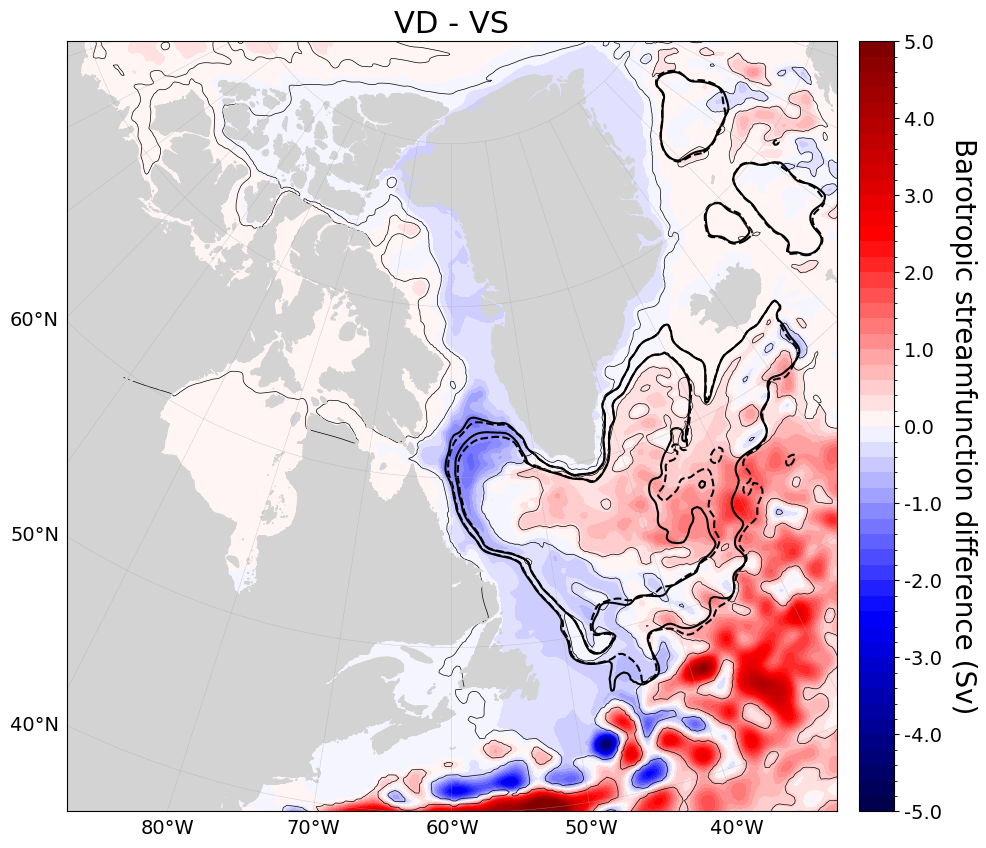

In [39]:
from mpl_toolkits.basemap import Basemap
from matplotlib.colors import BoundaryNorm
import matplotlib as mpl

fig, ax = plt.subplots(figsize=(10, 10))

vmin = -5
vmax = 5
levels = 50
lv = (vmax - vmin)/levels
levels = list(np.arange(vmin, vmax+lv, lv))
cmap = plt.get_cmap('seismic')

dif[np.where(dif > vmax)] = vmax
data = dif 
title = 'VD - VS'

ax.set_title(title, fontsize=22)
m = Basemap(projection='aea', resolution='f', width=5E6, height=5E6,
            lat_0=63, lon_0=-60, ax=ax)
m.contourf(lon[1:799,1:543], lat[1:799,1:543], data, latlon=True, levels=levels, vmin=vmin, vmax=vmax, cmap=cmap)

x, y = m(lon, lat)

m.contour(x[1:799,1:543], y[1:799,1:543], p_val,[np.nanmin(p_val), 0.01], colors = 'black', 
          linestyles = '-', linewidths = 0.5)
m.contour(x[1:799,1:543], y[1:799,1:543], vd_avg,[-10, -5], colors = 'black', linestyles = '-', linewidths = 1.5)
m.contour(x[1:799,1:543], y[1:799,1:543], vs_avg,[-10, -5], colors = 'black', 
          linestyles = 'dashed', linewidths = 1.5)


m.drawcoastlines(color='lightgray')
m.fillcontinents(color='lightgray', lake_color='lightgray')
m.drawmeridians(np.arange(0,360,10), labels=[0, 0, 0, 1], linewidth=0.4, color='darkgray', fontsize=14)
m.drawparallels(np.arange(-90,90,10), labels=[1, 0, 0, 0], linewidth=0.4, color='darkgray', fontsize=14)

# Colorbar
cax = fig.add_axes([0.92, 0.11, 0.035, 0.77])
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
    
n_ticks = 11
ticks = np.linspace(levels[0], levels[-1], n_ticks)
    
cb = mpl.colorbar.ColorbarBase(cax, cmap=cmap, norm=norm,
                                  boundaries=levels,
                                  ticks=ticks,
                                  spacing='proportional')
cb.ax.tick_params(labelsize=14)
if vmax > 20:
    cb.set_ticklabels([f"{t:.0f}" for t in ticks])
else:
    cb.set_ticklabels([f"{t:.1f}" for t in ticks])
        
cb.set_label('Barotropic streamfunction difference (Sv)', rotation=270, labelpad=25, fontsize=20)


figure_title = 'BSTFdifference'
os.chdir('.../Figures9&11_BarotropicStreamfunction/')
plt.savefig(figure_title + '.png', dpi=300, bbox_inches='tight')
plt.show()



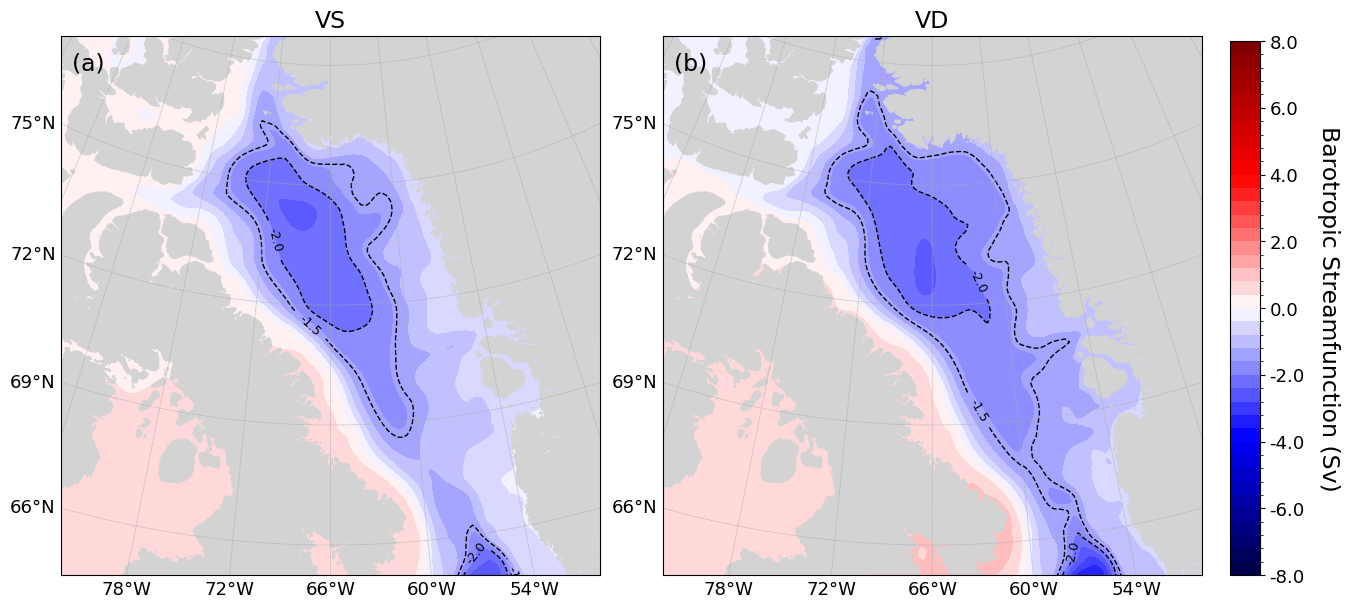

In [41]:
vmin = -8
vmax = 8
levels = 40
lv = (vmax - vmin) / levels
levels = np.arange(vmin, vmax + lv, lv)
cmap = plt.get_cmap('seismic')
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

# 🎯 Dataset dictionary: can be raw values or precomputed differences
data_dict = {'VS': vs_avg,  'VD': vd_avg}

fig, axs = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)

for ax, (name, data) in zip(axs, data_dict.items()):
    
    ax.set_title(name, fontsize=17)
    
    m = Basemap(projection='stere', width=1.5e6, height=1.5e6, lat_0=72, lon_0=-66, resolution = 'f', ax=ax)
    
    x, y = lon[1:799, 1:543], lat[1:799, 1:543] 
    
    m.contourf(x, y, data, latlon=True, levels=levels, vmin=vmin, vmax=vmax, cmap=cmap)
    cs = m.contour(x, y, data, latlon=True, levels=[ -2, -1.5], colors='black', linewidths=1.0)
    plt.clabel(cs, fmt='%1.1f', fontsize=9)

    m.drawcoastlines(color='lightgray')
    m.fillcontinents(color='lightgray', lake_color='lightgray')
    m.drawmeridians(np.arange(0, 360, 6), labels=[0, 0, 0, 1], linewidth=0.6, color='darkgray', fontsize=13)
    m.drawparallels(np.arange(-90, 90, 3), labels=[1, 0, 0, 0], linewidth=0.6, color='darkgray', fontsize=13)

# 🎚️ Shared colorbar
cax = fig.add_axes([1.02, 0.05, 0.025, 0.89])
cb = mpl.colorbar.ColorbarBase(cax, cmap=cmap, norm=norm, orientation='vertical')
cb.set_label('Barotropic Streamfunction (Sv)', rotation=270, labelpad=25, fontsize = 17)

ticks = np.arange(vmin, vmax + 0.01, 2)
cb.set_ticks(ticks)
cb.set_ticklabels([f"{t:.1f}" for t in ticks])
cb.ax.tick_params(labelsize=13)  

labels = ['a', 'b']

for i, ax in enumerate(axs):
    ax.text(0.02, 0.97, f'({labels[i]})', transform=ax.transAxes,
            fontsize=17, va='top', ha='left')
    
figure_title = 'BSTF_BaffinBay_VDandVS'
os.chdir('.../Figures9&11_BarotropicStreamfunction/')
plt.savefig(figure_title + '.png', dpi=300, bbox_inches='tight')
plt.show()